In [ ]:
%pip install numpy
%pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np
%pip install mrcfile
import mrcfile
%pip install gdown
import gdown
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
#import io


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
# %pip install mrcfile

import mrcfile

# %pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Install Biopython for PDB parsing
%pip install biopython
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D

# Set random seed for reproducibility
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.7 MB/s eta 0:00:00


Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=decad117-2298-4b10-90df-f15a494f95eb
To: /content/map.mrc
100%|██████████| 228M/228M [00:03<00:00, 65.4MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


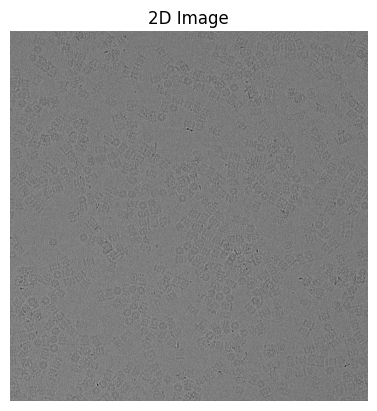

In [ ]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

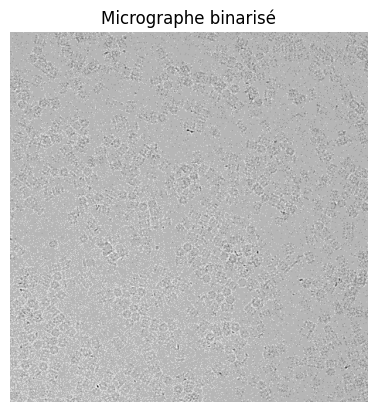

In [ ]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned


binned = bin_image(data, 4)
plt.imshow(binned, cmap='gray')
plt.title("Micrographe binarisé")
plt.axis('off')
plt.show()

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=2f794c60-6895-4c57-bdc8-441dbb0560b8
To: /content/map.mrc
100%|██████████| 228M/228M [00:01<00:00, 210MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (1919, 1855)
Dtype: uint8
Min/Max: 8 22

Detected: single 2D image


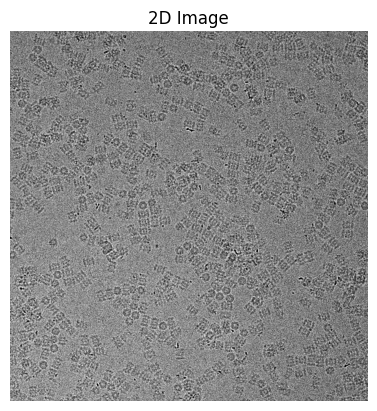

In [ ]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = bin_image(mrc.data,4)

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

Normalizing the image

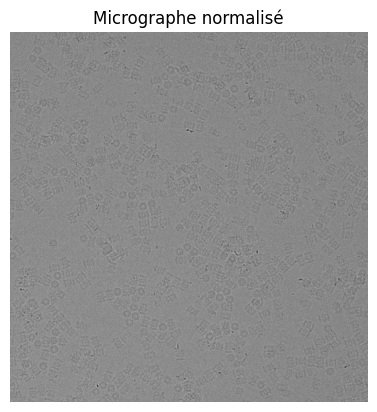

In [ ]:
import cv2
binned_norm = cv2.normalize(data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(binned_norm, cmap='gray')
plt.title("Micrographe normalisé")
plt.axis('off')
plt.show()

Padding

In [ ]:
def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:
    -----------
    img : ndarray
        Input image
    pad_width : int or tuple
        Number of pixels to pad on each side
    mode : str
        Padding mode: 'constant', 'edge', 'reflect', 'wrap'
    constant_value : int
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded

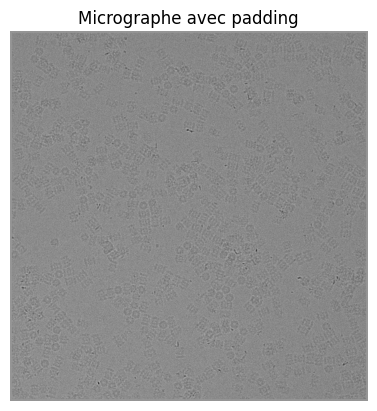

In [ ]:
 padding1 = apply_padding(binned_norm, 10, mode='constant', constant_value=150)

 plt.imshow(padding1, cmap='gray')
 plt.title("Micrographe avec padding")
 plt.axis('off')
 plt.show()

Check the image format Pour utiliser le NCC on doit utiliser comme format d'image float32

In [ ]:
print(data.dtype)
print(binned_norm.dtype)
print(padding1.dtype)

data_convertit = data.astype(np.float32)
binned_norm_convertit = binned_norm.astype(np.float32)
padding1_convertit = padding1.astype(np.float32)

print(data_convertit.dtype)
print(binned_norm_convertit.dtype)
print(padding1_convertit.dtype)

uint8
uint8
uint8
float32
float32
float32


Denoising

-> Nettoyage de l'image de test ...
Taille de l'image de test : (512, 512)


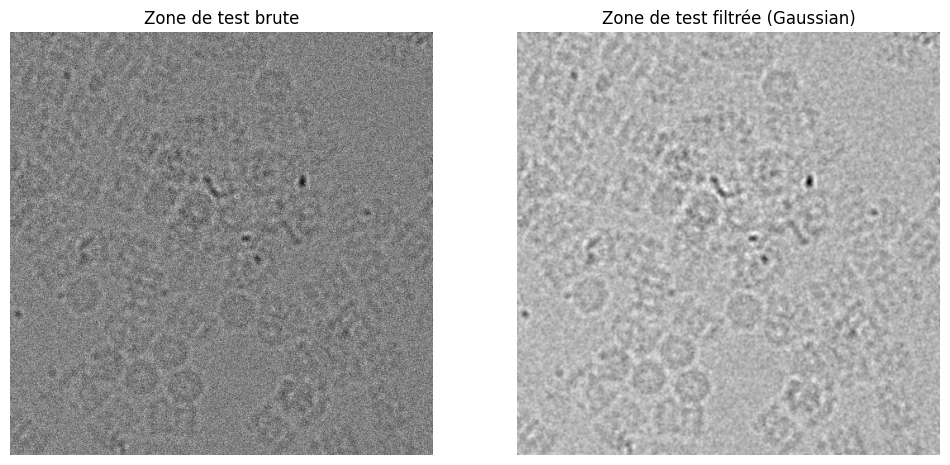

In [ ]:

from skimage import filters



h, w = padding1_convertit.shape
start_y, start_x = h//2, w//2
img_test_raw = padding1_convertit[start_y:start_y+512, start_x:start_x+512]

print("-> Nettoyage de l'image de test ...")


img_test = filters.gaussian(img_test_raw, sigma=1)

print(f"Taille de l'image de test : {img_test.shape}")


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_test_raw, cmap='gray')
axes[0].set_title("Zone de test brute")
axes[0].axis('off')

axes[1].imshow(img_test, cmap='gray')
axes[1].set_title("Zone de test filtrée (Gaussian)")
axes[1].axis('off')

plt.show()

Prepare the PDB
IL FAUT AUSSI NORMALISER LES PROJECTIONS


In [ ]:

pdb_id = "6BDF"
pdb_file = f"{pdb_id}.pdb"

print(f"-> Récupération de la structure {pdb_id.upper()}...")

# 1. Téléchargement automatique (uniquement si on ne l'a pas déjà)
if not os.path.exists(pdb_file):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    try:
        urllib.request.urlretrieve(url, pdb_file)
        print("Téléchargement terminé !")
    except Exception as e:
        print(f"Erreur de téléchargement : Vérifie que l'ID {pdb_id} existe bien.")
else:
    print("Le fichier PDB est déjà présent dans les dossiers.")

# 2. Lecture et vérification du PDB avec Biopython
print("-> Analyse du fichier PDB...")
# J'utilise QUIET=True pour cacher les petits avertissements sans importance de Biopython
parser = PDBParser(QUIET=True)

try:
    structure = parser.get_structure(pdb_id, pdb_file)

    # Je compte les atomes pour vérifier que le fichier n'est pas vide
    nb_atomes = len(list(structure.get_atoms()))

    print("Succès ! Structure chargée.")
    print(f"Nombre total d'atomes trouvés : {nb_atomes}")

except FileNotFoundError:
    print("Le fichier n'a pas été trouvé, le téléchargement a dû échouer.")

-> Récupération de la structure 6BDF...
Téléchargement terminé !
-> Analyse du fichier PDB...
Succès ! Structure chargée.
Nombre total d'atomes trouvés : 46382


Template

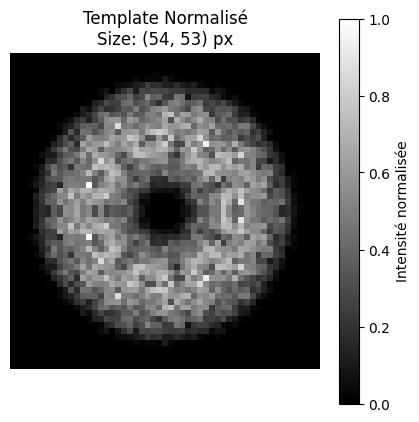

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_ncc_template(coords, target_px=2.64, padding=10):
    # Centrage
    coords_centered = coords - coords.mean(axis=0)

    # Box Size en Angstroms
    x_range = [coords_centered[:, 0].min() - padding, coords_centered[:, 0].max() + padding]
    y_range = [coords_centered[:, 1].min() - padding, coords_centered[:, 1].max() + padding]

    # Nombre de pixels (calé sur le binning 4)
    width_px = int(np.ceil((x_range[1] - x_range[0]) / target_px))
    height_px = int(np.ceil((y_range[1] - y_range[0]) / target_px))

    # Histogramme 2D (Somme de densité)
    H, _, _ = np.histogram2d(
        coords_centered[:, 0], coords_centered[:, 1],
        bins=[width_px, height_px],
        range=[x_range, y_range]
    )

    # Transpose pour remettre les axes X/Y dans le bon sens (Matplotlib/OpenCV)
    template = H.T.astype(np.float32)

    # --- NORMALISATION ---
    # Option A: Min-Max (ce que tu as fait, très bien pour le contraste)
    template_norm = cv2.normalize(template, None, 0, 1, cv2.NORM_MINMAX)

    # Option B: Inversion (Si ta protéine est noire sur fond blanc dans le MRC)
    # template_norm = 1.0 - template_norm

    return template_norm

# Utilisation
template_ready = generate_ncc_template(coords, target_px=2.64)

# Visualisation pour vérification
plt.figure(figsize=(5,5))
plt.imshow(template_ready, cmap='gray')
plt.title(f"Template Normalisé\nSize: {template_ready.shape} px")
plt.colorbar(label="Intensité normalisée")
plt.axis('off')
plt.show()

add artificial noise
